CELL 1 — Install dependencies

In [ ]:
!pip install umap-learn -q

CELL 2 — Mount Drive + Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pickle
import warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
import umap
warnings.filterwarnings('ignore')

BASE_DIR = '/content/drive/MyDrive/mars_project'

print("Loading Phase 1 model...")
model = load_model(os.path.join(BASE_DIR, 'mars_phase1_efficientnet.keras'))
print(f"Model loaded — {len(model.layers)} top-level layers.")

with open(os.path.join(BASE_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES  = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Phase 1 model...
Model loaded — 9 top-level layers.
Classes: [np.str_('cracked'), np.str_('gravel'), np.str_('sand'), np.str_('sedimentary')]


 CELL 3 — Load test images

In [ ]:
def load_images_and_labels(data_dir):
    images, labels, paths = [], [], []
    valid_exts = ('.jpg', '.jpeg', '.png')
    for file_name in sorted(os.listdir(data_dir)):
        if not file_name.lower().endswith(valid_exts):
            continue
        if '_' not in file_name:
            continue
        img_path = os.path.join(data_dir, file_name)
        try:
            img = Image.open(img_path).convert('RGB').resize((224, 224))
        except Exception:
            continue
        images.append(np.array(img) / 255.0)
        labels.append(file_name.split('_')[0])
        paths.append(img_path)
    return np.array(images, dtype=np.float32), np.array(labels), paths

test_dir = os.path.join(BASE_DIR, 'test')
test_images, test_labels, test_paths = load_images_and_labels(test_dir)
test_enc = label_encoder.transform(test_labels)
print(f"Loaded {len(test_images)} test images")

Loaded 81 test images


CELL 4 — Find the correct Grad-CAM layer

In [ ]:
def find_last_conv_layer(model):
    """
    Walks the model (including any nested sub-models) and returns
    the name of the last Conv2D layer suitable for Grad-CAM.
    For EfficientNetB3 this is always 'top_conv'.
    """
    last_conv_name = None

    for layer in model.layers:
        # Direct Conv2D at top level
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_name = layer.name

        # EfficientNet is a nested Model — search inside it
        elif isinstance(layer, tf.keras.Model):
            for sublayer in layer.layers:
                if isinstance(sublayer, tf.keras.layers.Conv2D):
                    last_conv_name = sublayer.name

    return last_conv_name


last_conv_layer = find_last_conv_layer(model)
print(f"Last Conv2D for Grad-CAM: '{last_conv_layer}'")

# If it prints None, uncomment the line below and set manually:
# last_conv_layer = 'top_conv'

Last Conv2D for Grad-CAM: 'top_conv'


CELL 5 — Grad-CAM implementation

In [ ]:
def build_gradcam_model(model, last_conv_layer_name):
    # 1. Find the nested EfficientNet model
    base_model = next((l for l in model.layers if isinstance(l, tf.keras.Model)), None)
    if not base_model:
        raise ValueError("Could not find EfficientNet base model.")

    # 2. Create the inner model that outputs both the target conv maps and its final output
    inner_grad_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    return inner_grad_model, base_model, model


def make_gradcam_heatmap(img_array, grad_models, pred_index=None):
    inner_grad_model, base_model, full_model = grad_models

    with tf.GradientTape() as tape:
        x = tf.cast(img_array, tf.float32)

        # 3. Walk through the model layer by layer
        for layer in full_model.layers:
            # SKIP the Input layer to prevent the exact TypeError you just got
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue

            # If it's the EfficientNet base model, swap it for our inner_grad_model
            if layer == base_model:
                conv_out, x = inner_grad_model(x)
                tape.watch(conv_out) # Tell TensorFlow to watch this specific tensor!
            else:
                # Run standard layers (Dense, Dropout, GAP, etc.) normally
                x = layer(x)

        predictions = x
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    # 4. Now the gradient flows perfectly backwards
    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)

    # 5. Safely normalize
    max_val = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_val + 1e-8)

    return heatmap.numpy()


def overlay_gradcam(original_img, heatmap, alpha=0.45):
    img_uint8 = (original_img * 255).astype(np.uint8)
    heatmap_uint8  = np.uint8(255 * heatmap)
    heatmap_pil    = Image.fromarray(heatmap_uint8).resize((224, 224))
    heatmap_np     = np.array(heatmap_pil) / 255.0
    colormap       = matplotlib.colormaps['jet']
    heatmap_rgb    = (colormap(heatmap_np)[:, :, :3] * 255).astype(np.uint8)
    blended = (img_uint8 * (1 - alpha) + heatmap_rgb * alpha).astype(np.uint8)
    return blended


# Build the Grad-CAM dictionary
grad_model = build_gradcam_model(model, last_conv_layer)
print("Grad-CAM model built successfully.")

Grad-CAM model built successfully.


CELL 6 — Visualize Grad-CAM for 2 images per class

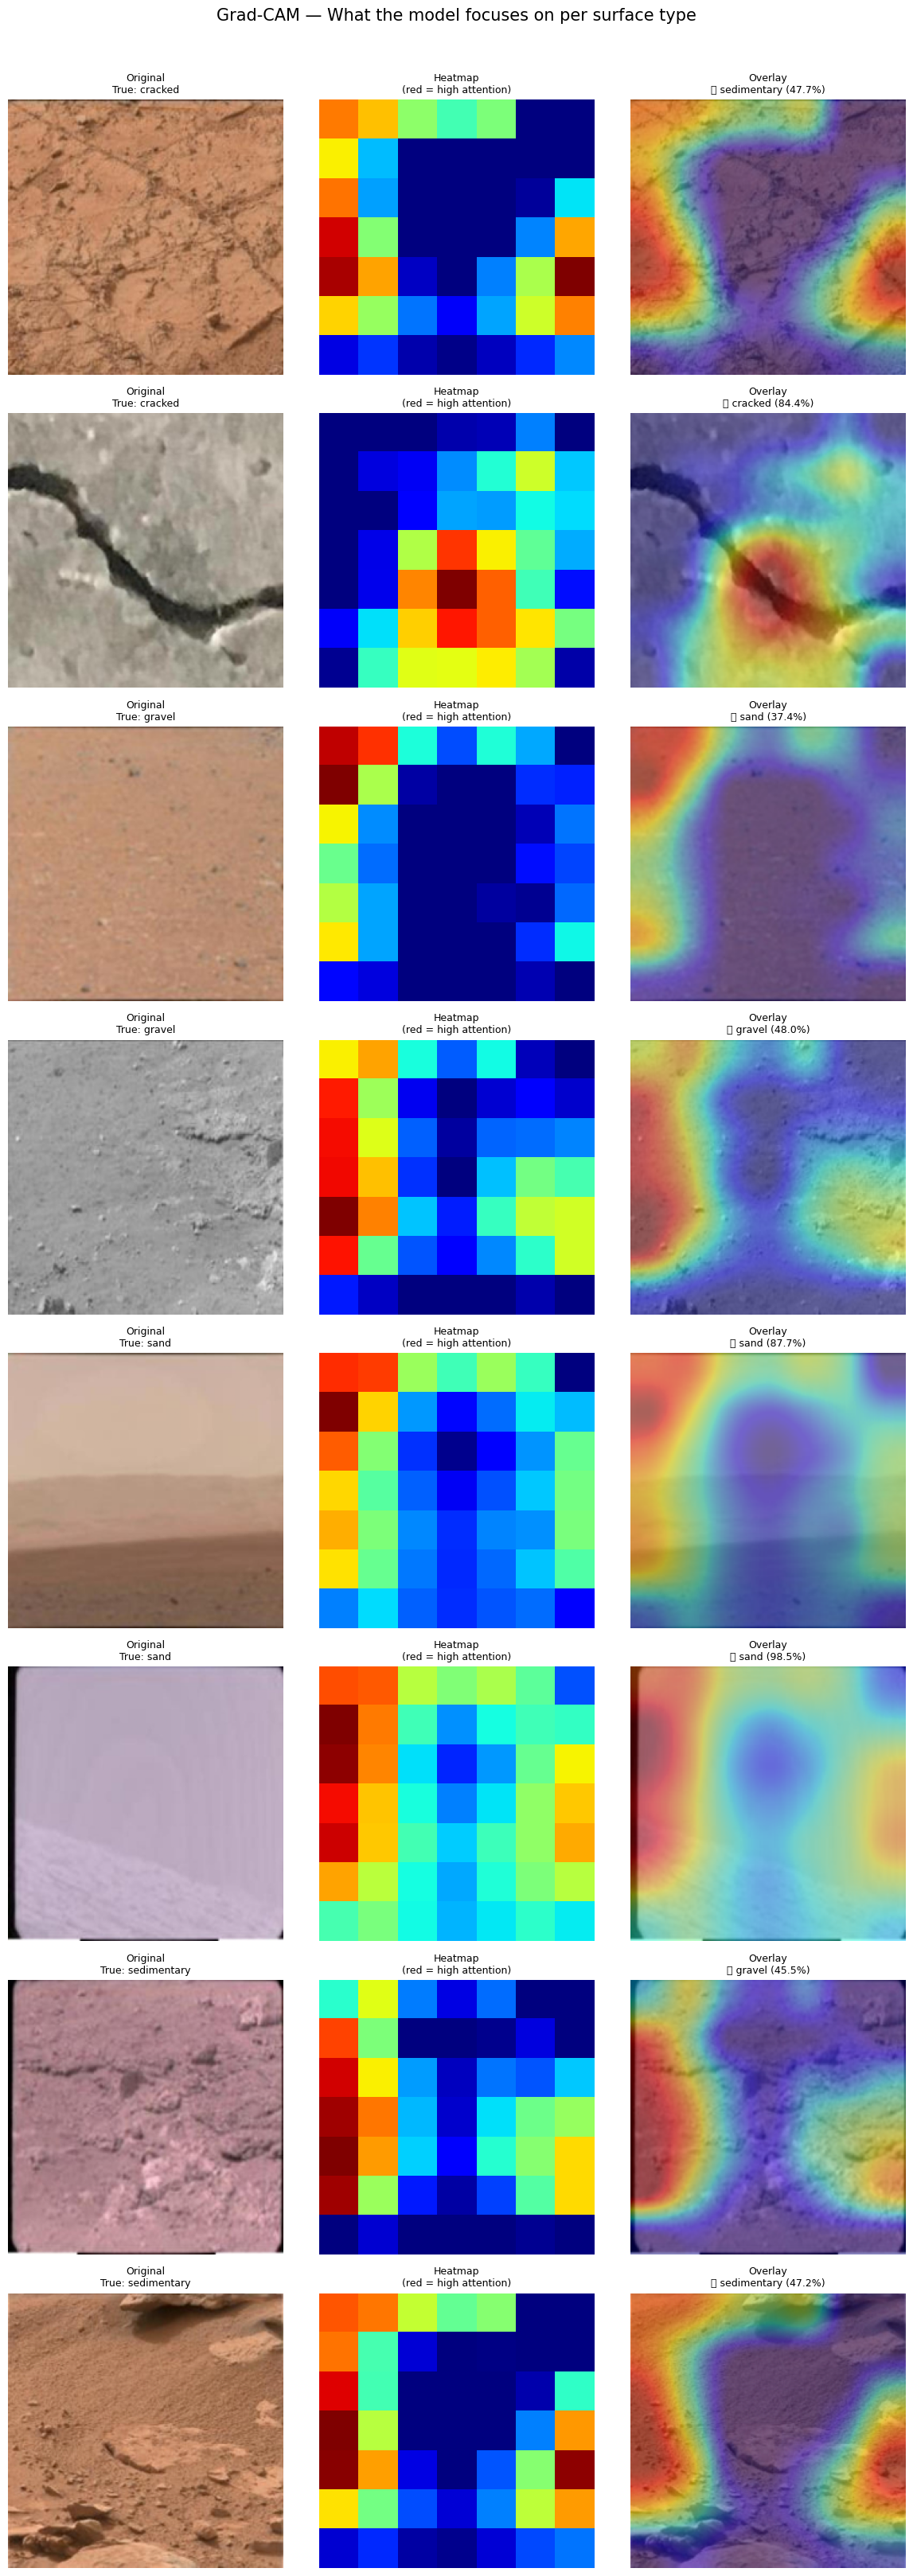

Grad-CAM saved: /content/drive/MyDrive/mars_project/phase2_gradcam.png


In [ ]:
samples_per_class = 2
viz_indices = []
for cls_idx in range(NUM_CLASSES):
    idxs = np.where(test_enc == cls_idx)[0]
    viz_indices.extend(idxs[:samples_per_class].tolist())

n_rows = len(viz_indices)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 4 * n_rows))
if n_rows == 1:
    axes = [axes]   # keep consistent shape

fig.suptitle('Grad-CAM — What the model focuses on per surface type',
             fontsize=15, y=1.01)

for row, idx in enumerate(viz_indices):
    img        = test_images[idx]
    true_label = test_labels[idx]
    img_input  = np.expand_dims(img, axis=0)

    preds      = model.predict(img_input, verbose=0)
    pred_idx   = int(np.argmax(preds[0]))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = preds[0][pred_idx] * 100

    heatmap  = make_gradcam_heatmap(img_input, grad_model, pred_idx)
    overlaid = overlay_gradcam(img, heatmap)

    tick = '✅' if pred_label == true_label else '❌'

    axes[row][0].imshow(img)
    axes[row][0].set_title(f'Original\nTrue: {true_label}', fontsize=9)
    axes[row][0].axis('off')

    axes[row][1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    axes[row][1].set_title('Heatmap\n(red = high attention)', fontsize=9)
    axes[row][1].axis('off')

    axes[row][2].imshow(overlaid)
    axes[row][2].set_title(f'Overlay\n{tick} {pred_label} ({confidence:.1f}%)', fontsize=9)
    axes[row][2].axis('off')

plt.tight_layout()
out_path = os.path.join(BASE_DIR, 'phase2_gradcam.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM saved: {out_path}")

CELL 7 — Extract embeddings (128-dim feature vectors)

In [ ]:
# Find the Dense(128) embedding layer (second-to-last Dense)
dense_layers = [l for l in model.layers
                if isinstance(l, tf.keras.layers.Dense)]
print("All Dense layers:", [(l.name, l.units) for l in dense_layers])

# The layer order: Dense(256) → Dense(128) → Dense(num_classes/softmax)
# We want Dense(128) — index -2 from the dense list
embedding_layer_name = dense_layers[-2].name
print(f"\nUsing embedding layer: '{embedding_layer_name}' (128-dim)")

embedding_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer(embedding_layer_name).output
)

print("Extracting embeddings from all test images...")
all_embeddings = embedding_model.predict(test_images, batch_size=16, verbose=1)
print(f"Embedding matrix shape: {all_embeddings.shape}")  # (N_test, 128)

# Save for Phase 3
np.save(os.path.join(BASE_DIR, 'embeddings.npy'), all_embeddings)
print("embeddings.npy saved.")

All Dense layers: [('dense_256', 256), ('dense_128', 128), ('predictions', 4)]

Using embedding layer: 'dense_128' (128-dim)
Extracting embeddings from all test images...
6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step
Embedding matrix shape: (81, 128)
embeddings.npy saved.


CELL 8 — UMAP + t-SNE visualization

Running UMAP (2-D projection)...
Running t-SNE (perplexity=20)...


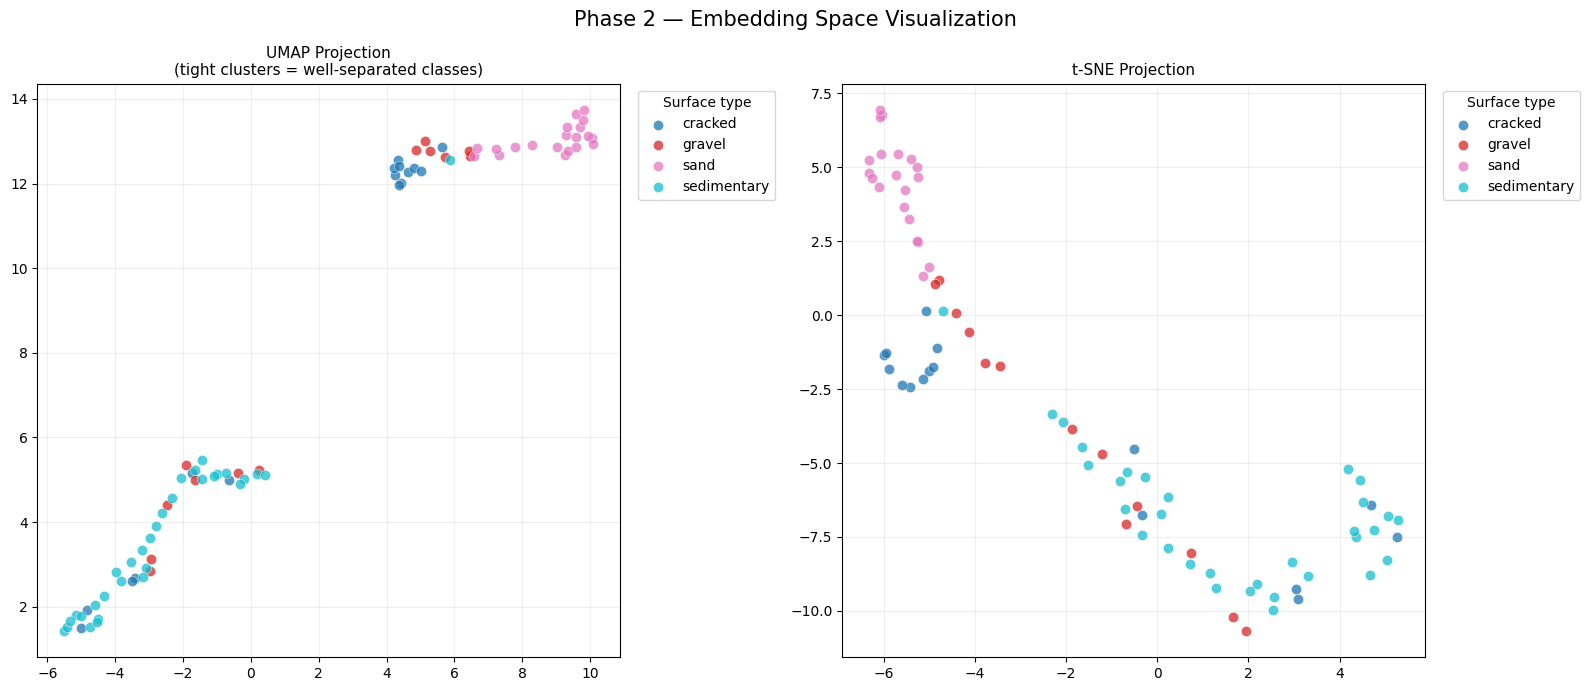

Embedding visualization saved: /content/drive/MyDrive/mars_project/phase2_embeddings.png


In [ ]:
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

# --- UMAP ---
print("Running UMAP (2-D projection)...")
reducer_umap       = umap.UMAP(n_components=2, random_state=42,
                                n_neighbors=15, min_dist=0.1)
embeddings_umap    = reducer_umap.fit_transform(all_embeddings)

# --- t-SNE ---
# perplexity must be < n_samples; clamp it safely
perplexity = min(30, max(5, len(test_images) // 4))
print(f"Running t-SNE (perplexity={perplexity})...")
reducer_tsne       = TSNE(n_components=2, random_state=42,
                          perplexity=perplexity, n_iter=1000)
embeddings_tsne    = reducer_tsne.fit_transform(all_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Phase 2 — Embedding Space Visualization', fontsize=15)

for ax, emb, title in zip(
    axes,
    [embeddings_umap, embeddings_tsne],
    ['UMAP Projection\n(tight clusters = well-separated classes)',
     't-SNE Projection']
):
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = test_enc == cls_idx
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   label=cls_name, color=colors[cls_idx],
                   alpha=0.75, s=55,
                   edgecolors='white', linewidths=0.4)
    ax.set_title(title, fontsize=11)
    ax.legend(title='Surface type', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
out_path = os.path.join(BASE_DIR, 'phase2_embeddings.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Embedding visualization saved: {out_path}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pickle
from PIL import Image

# Redefine the missing variable
BASE_DIR = '/content/drive/MyDrive/mars_project'

# 1. Reload the label encoder
with open(os.path.join(BASE_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)
CLASS_NAMES = list(label_encoder.classes_)
print(f"Classes loaded: {CLASS_NAMES}")

# 2. Reload the test images and labels directly from the test folder
print("Reloading test dataset into memory...")
test_images, test_labels = [], []
test_dir = os.path.join(BASE_DIR, 'test')

# Fixed the typo here: os.listdir instead of os.path.listdir
for fname in sorted(os.listdir(test_dir)):
    if '_' in fname:
        cls_name = fname.split('_')[0]
        if cls_name in CLASS_NAMES:
            img_path = os.path.join(test_dir, fname)
            try:
                img = Image.open(img_path).convert('RGB').resize((224, 224))
                test_images.append(np.array(img) / 255.0)
                test_labels.append(cls_name)
            except Exception:
                continue

test_images = np.array(test_images, dtype=np.float32)
test_enc = np.array([CLASS_NAMES.index(c) for c in test_labels])

print(f"Successfully reloaded {len(test_images)} images from the test folder!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes loaded: [np.str_('cracked'), np.str_('gravel'), np.str_('sand'), np.str_('sedimentary')]
Reloading test dataset into memory...
Successfully reloaded 81 images from the test folder!


In [ ]:
import tensorflow as tf
import os

print("Loading saved model...")
model_path = os.path.join(BASE_DIR, 'mars_phase1_efficientnet.keras')

# Load the model you saved at the end of Phase 1
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")

Loading saved model...
Model loaded successfully!


CELL 9 — Monte Carlo Dropout Uncertainty Estimation

In [ ]:
def mc_dropout_predict(model, img_array, n_passes=50):
    preds = []
    for _ in range(n_passes):
        x = tf.cast(img_array, tf.float32)

        # Walk through the layers manually
        for layer in model.layers:
            # 1. SKIP the Input layer entirely to prevent the TypeError
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue

            # 2. ONLY turn on training mode for the Dropout layers!
            if isinstance(layer, tf.keras.layers.Dropout):
                x = layer(x, training=True)
            else:
                # 3. Keep everything else frozen, with a safety net for strict layers
                try:
                    x = layer(x, training=False)
                except TypeError:
                    x = layer(x) # Fallback for layers that refuse the 'training' argument

        preds.append(x.numpy()[0])

    preds = np.stack(preds)
    mean_pred = preds.mean(axis=0)
    std_pred  = preds.std(axis=0)
    entropy   = -np.sum(mean_pred * np.log(mean_pred + 1e-8))

    return mean_pred, std_pred, entropy


print(f"Running MC Dropout (50 passes × {len(test_images)} images)...")
all_means, all_stds, all_entropies = [], [], []

for i, img in enumerate(test_images):
    if i % max(1, len(test_images) // 10) == 0:
        print(f"  {i}/{len(test_images)} images done...")
    img_input = np.expand_dims(img, axis=0)
    mean, std, entropy = mc_dropout_predict(model, img_input, n_passes=50)
    all_means.append(mean)
    all_stds.append(std.mean())
    all_entropies.append(entropy)

all_means     = np.array(all_means)
all_stds      = np.array(all_stds)
all_entropies = np.array(all_entropies)

np.save(os.path.join(BASE_DIR, 'entropies.npy'), all_entropies)
print(f"\nDone. Entropy saved.")
print(f"Mean entropy: {all_entropies.mean():.4f}  |  Max: {all_entropies.max():.4f}")

Running MC Dropout (50 passes × 81 images)...
  0/81 images done...
  8/81 images done...
  16/81 images done...
  24/81 images done...
  32/81 images done...
  40/81 images done...
  48/81 images done...
  56/81 images done...
  64/81 images done...
  72/81 images done...
  80/81 images done...

Done. Entropy saved.
Mean entropy: 0.9199  |  Max: 1.3493


In [13]:
import matplotlib.pyplot as plt

CELL 10 — Plot uncertainty analysis

MC Dropout accuracy: 65.43%


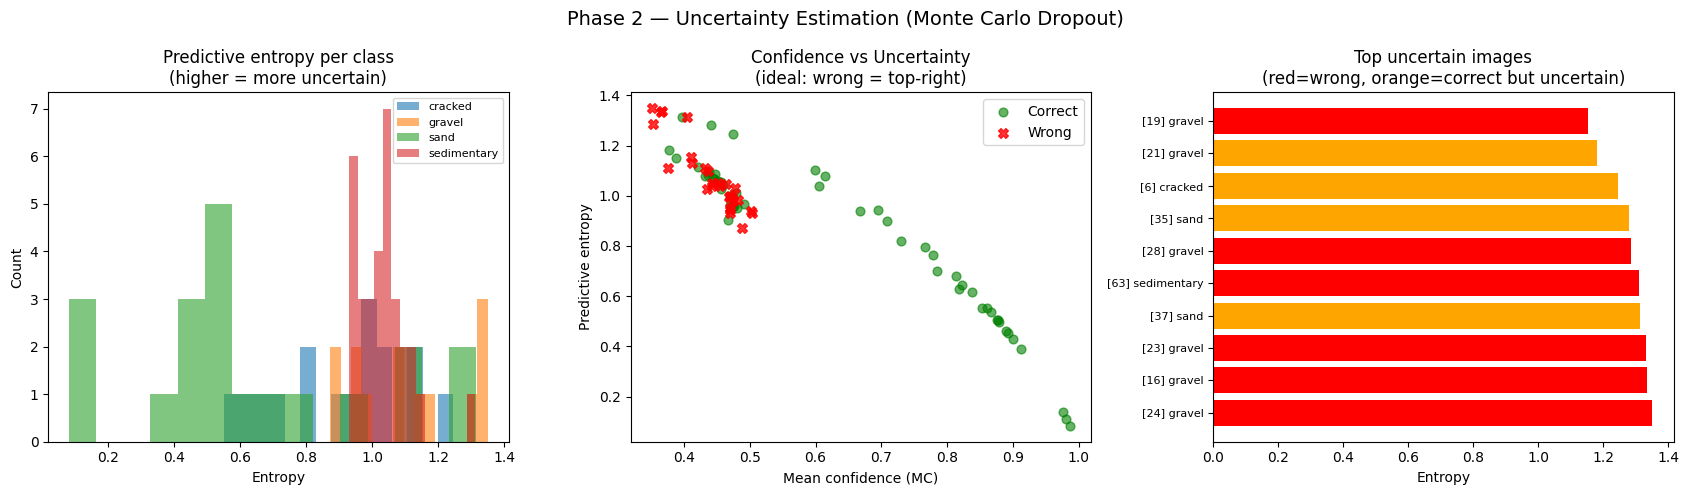

Uncertainty plot saved: /content/drive/MyDrive/mars_project/phase2_uncertainty.png

✅ PHASE 2 COMPLETE — open Phase 3 notebook next


In [14]:
final_preds    = np.argmax(all_means, axis=1)
max_confidence = all_means.max(axis=1)
correct        = (final_preds == test_enc)
mc_accuracy    = correct.mean() * 100
print(f"MC Dropout accuracy: {mc_accuracy:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Phase 2 — Uncertainty Estimation (Monte Carlo Dropout)', fontsize=14)

# 1. Entropy distribution per class
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = test_enc == cls_idx
    axes[0].hist(all_entropies[mask], alpha=0.6, label=cls_name, bins=15)
axes[0].set_title('Predictive entropy per class\n(higher = more uncertain)')
axes[0].set_xlabel('Entropy')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# 2. Confidence vs entropy scatter — wrong predictions should be high entropy
axes[1].scatter(max_confidence[correct],  all_entropies[correct],
                alpha=0.6, c='green', s=40, label='Correct')
axes[1].scatter(max_confidence[~correct], all_entropies[~correct],
                alpha=0.8, c='red',   s=50, label='Wrong', marker='X')
axes[1].set_title('Confidence vs Uncertainty\n(ideal: wrong = top-right)')
axes[1].set_xlabel('Mean confidence (MC)')
axes[1].set_ylabel('Predictive entropy')
axes[1].legend()

# 3. Top-10 most uncertain test images
safe_n   = min(10, len(all_entropies))
top_unc  = np.argsort(all_entropies)[-safe_n:][::-1]
bar_cols = ['red' if not correct[i] else 'orange' for i in top_unc]
axes[2].barh(range(safe_n), all_entropies[top_unc], color=bar_cols)
axes[2].set_yticks(range(safe_n))
axes[2].set_yticklabels(
    [f"[{i}] {test_labels[i]}" for i in top_unc], fontsize=8
)
axes[2].set_title('Top uncertain images\n(red=wrong, orange=correct but uncertain)')
axes[2].set_xlabel('Entropy')

plt.tight_layout()
out_path = os.path.join(BASE_DIR, 'phase2_uncertainty.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Uncertainty plot saved: {out_path}")
print("\n✅ PHASE 2 COMPLETE — open Phase 3 notebook next")